In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

cuda
NVIDIA RTX 2000 Ada Generation


In [17]:
#setting the path
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "plantvillage dataset"
IMAGE_SET = DATA_ROOT / "color"


print("Project root:", PROJECT_ROOT)
print("Data root exists:", DATA_ROOT.exists())
print("Using image set:", IMAGE_SET)
print("Classes:", len([p for p in IMAGE_SET.iterdir() if p.is_dir()]))

Project root: c:\Users\KBE\Desktop\plant-disease-project
Data root exists: True
Using image set: c:\Users\KBE\Desktop\plant-disease-project\data\plantvillage dataset\color
Classes: 38


In [18]:
# store data in a pandas dataframe
import pandas as pd

class_dirs = sorted([p for p in IMAGE_SET.iterdir() if p.is_dir()])

rows = []
for class_dir in class_dirs:
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        for fp in class_dir.glob(ext):
            rows.append({
                "filepath": str(fp),
                "class_name": class_dir.name
            })

df = pd.DataFrame(rows)
class_to_idx = {name: i for i, name in enumerate(sorted(df["class_name"].unique()))}
df["label"] = df["class_name"].map(class_to_idx)
df["image_id"] = df["filepath"].map(lambda x: Path(x).stem)


print(df.columns.tolist())

print("Total images:", len(df))
print("Total classes:", df["class_name"].nunique())
display(df.head())
display(df["class_name"].value_counts().head(10))

['filepath', 'class_name', 'label', 'image_id']
Total images: 174297
Total classes: 38


,filepath,class_name,label,image_id
0,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...
1,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...
2,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...
3,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...
4,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...


class_name
Orange___Haunglongbing_(Citrus_greening)      33042
Peach___Bacterial_spot                        13782
Apple___healthy                                9835
Blueberry___healthy                            9012
Grape___Esca_(Black_Measles)                   8298
Corn_(maize)___Common_rust_                    7152
Grape___Black_rot                              7080
Corn_(maize)___healthy                         6967
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)     6456
Cherry_(including_sour)___Powdery_mildew       6312
Name: count, dtype: int64

In [26]:
# using phash to calculate perceptual hash of images
import imagehash
from PIL import Image

def calculate_phash(filepath):
    try:
        with Image.open(filepath) as image:
            image = image.convert("RGB")
            return str(imagehash.phash(image))
    except Exception as error:
        print(f"Could not process {filepath}: {error}")
        return None


df["phash"] = df["filepath"].apply(calculate_phash)


df[["filepath", "class_name", "phash"]].head()


,filepath,class_name,phash
0,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,eeb185d21aca690f
1,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,e56071527beaa08f
2,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,de0c0d2b1675e8f2
3,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,a680bd9adbd42c5a
4,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,b4fca08e0e155f4b


In [27]:
# identify duplicate images based on perceptual hash
duplicate_rows = df[
    df.duplicated(subset="phash", keep=False)
].sort_values("phash")
print("Total dataset images:", len(df))
print("Rows belonging to duplicate groups:", len(duplicate_rows))
print("Number of duplicated hash groups:", duplicate_rows["phash"].nunique())

conflicting_groups = (
    df
    .dropna(subset=["phash"])
    .groupby("phash")["class_name"]
    .nunique()
)
conflicting_groups = conflicting_groups[conflicting_groups > 1]
print(
    "Duplicate groups containing different class labels:",
    len(conflicting_groups)
)


Total dataset images: 174297
Rows belonging to duplicate groups: 50
Number of duplicated hash groups: 25
Duplicate groups containing different class labels: 0


In [28]:
df["group_id"] = df["phash"]

duplicate_count = df.duplicated(
    subset=["phash", "class_name"]
).sum()
print("Duplicate rows to remove:", duplicate_count)

# Then drop the duplicates:
before_count = len(df)
df = (
    df
    .drop_duplicates(
        subset=["phash", "class_name"],
        keep="first"
    )
    .reset_index(drop=True)
)
after_count = len(df)
print("Images before duplicate removal:", before_count)
print("Images after duplicate removal:", after_count)
print("Duplicates removed:", before_count - after_count)


Duplicate rows to remove: 25
Images before duplicate removal: 174297
Images after duplicate removal: 174272
Duplicates removed: 25


In [32]:
from sklearn.model_selection import train_test_split

group_df = df[["group_id", "label"]].drop_duplicates()

train_groups, temp_groups = train_test_split(
    group_df,
    test_size=0.30,
    stratify=group_df["label"],
    random_state=42
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    stratify=temp_groups["label"],
    random_state=42
)

train_df = df[df["group_id"].isin(train_groups["group_id"])].reset_index(drop=True)
val_df   = df[df["group_id"].isin(val_groups["group_id"])].reset_index(drop=True)
test_df  = df[df["group_id"].isin(test_groups["group_id"])].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 121990
Val: 26141
Test: 26141


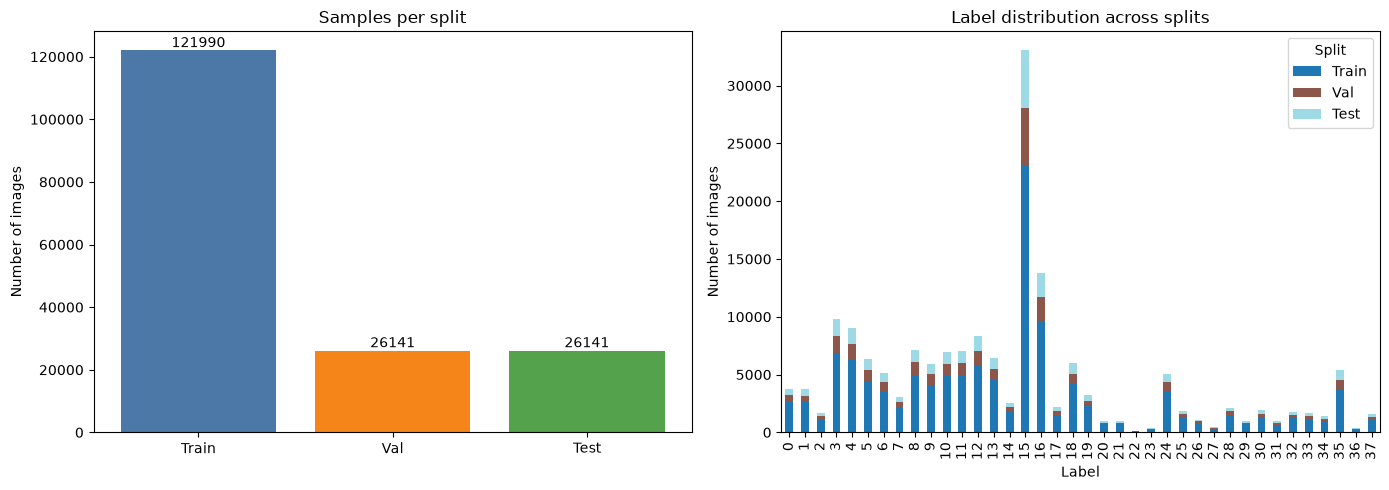

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Split sizes
split_sizes = {
    "Train": len(train_df),
    "Val": len(val_df),
    "Test": len(test_df)
}
axes[0].bar(split_sizes.keys(), split_sizes.values(), color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Samples per split")
axes[0].set_ylabel("Number of images")

for i, v in enumerate(split_sizes.values()):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# 2) Label distribution per split
dist_df = pd.DataFrame({
    "Train": train_df["label"].value_counts().sort_index(),
    "Val": val_df["label"].value_counts().sort_index(),
    "Test": test_df["label"].value_counts().sort_index()
}).fillna(0)

dist_df.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("Label distribution across splits")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Number of images")
axes[1].legend(title="Split")

plt.tight_layout()
plt.show()

In [31]:
print("train-val overlap:", len(set(train_df.group_id) & set(val_df.group_id)))
print("train-test overlap:", len(set(train_df.group_id) & set(test_df.group_id)))
print("val-test overlap:", len(set(val_df.group_id) & set(test_df.group_id)))

train-val overlap: 0
train-test overlap: 0
val-test overlap: 0


In [33]:
from tqdm.auto import tqdm
from torchvision import transforms

paths = train_df["filepath"].tolist()


channel_sum = torch.zeros(3)
channel_sum_sq = torch.zeros(3)
pixel_count = 0

for path in tqdm(paths, desc="Computing train mean/std"):
    img = Image.open(path).convert("RGB")
    x = transforms.ToTensor()(img)

    channel_sum += x.sum(dim=(1, 2))
    channel_sum_sq += (x ** 2).sum(dim=(1, 2))
    pixel_count += x.shape[1] * x.shape[2]

mean = channel_sum / pixel_count
std = ((channel_sum_sq / pixel_count) - (mean ** 2)).sqrt()

train_mean = mean.tolist()
train_std = std.tolist()

print("train_mean =", train_mean)
print("train_std  =", train_std)


Computing train mean/std:   0%|          | 0/121990 [00:00<?, ?it/s]

train_mean = [0.48664528131484985, 0.4931531846523285, 0.4604100286960602]
train_std  = [0.22834624350070953, 0.22082751989364624, 0.238686203956604]


In [35]:
rotation_fill = tuple(int(m * 255) for m in train_mean)
#Basic data augmentation for training images
basic_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10, fill=rotation_fill),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

# Field orientied augmentation for training images
field_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10, fill=rotation_fill),
    transforms.ColorJitter( brightness=0.25, contrast=0.20, saturation=0.15, hue=0.02),
    transforms.RandomApply([transforms.GaussianBlur( kernel_size=5, sigma=(0.1, 1.5))], p=0.20),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.15, scale=(0.01, 0.06), ratio=(0.5, 2.0), value="random"),
    transforms.Normalize( mean=train_mean,std=train_std )
])

#validation and test processing transform (no augmentation, just resizing and normalization)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

print("Basic training transform created.")
print("Field-oriented training transform created.")
print("Evaluation transform created.")

Basic training transform created.
Field-oriented training transform created.
Evaluation transform created.


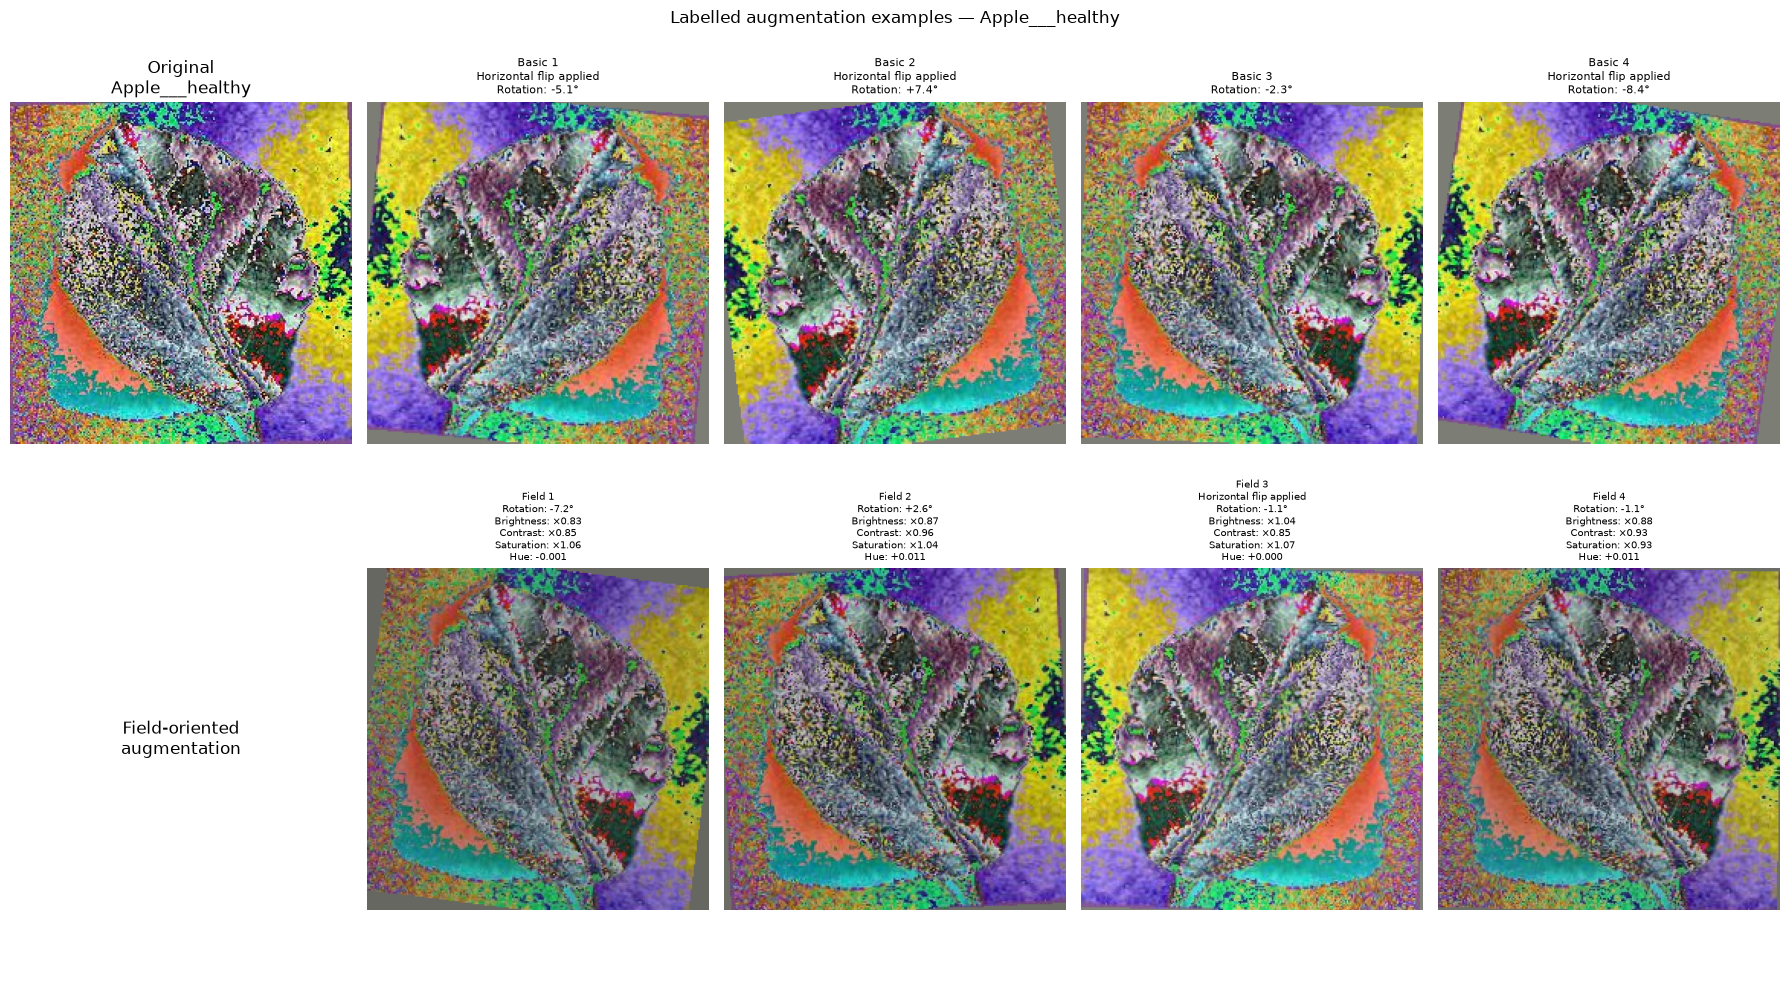

In [36]:
#Visualise augmented samples

import random
import torchvision.transforms.functional as TF
from PIL import Image
from torchvision.transforms import InterpolationMode

def denormalize_image(image_tensor, mean, std):
    image_tensor = image_tensor.clone()
    mean_tensor = torch.tensor(mean, dtype=image_tensor.dtype).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=image_tensor.dtype).view(3, 1, 1)
    image_tensor = image_tensor * std_tensor + mean_tensor
    return image_tensor.clamp(0, 1)

def tensor_to_display_image(image_tensor):
    image_tensor = denormalize_image( image_tensor, train_mean, train_std)
    return image_tensor.permute(1, 2, 0).numpy()

def labelled_basic_augmentation(image):
    labels = []
    image = TF.resize(image,[224, 224],interpolation=InterpolationMode.BILINEAR)
    if random.random() < 0.5:
        image = TF.hflip(image)
        labels.append("Horizontal flip applied")
    angle = random.uniform(-10, 10)
    image = TF.rotate(image, angle=angle, interpolation=InterpolationMode.BILINEAR, fill=rotation_fill)
    labels.append(f"Rotation: {angle:+.1f}°")
    image = TF.to_tensor(image)
    image = TF.normalize(image, mean=train_mean, std=train_std)
    return image, labels

def labelled_field_augmentation(image):
    labels = []
    image = TF.resize(image, [224, 224], interpolation=InterpolationMode.BILINEAR)
    if random.random() < 0.5:
        image = TF.hflip(image)
        labels.append("Horizontal flip applied")

    angle = random.uniform(-10, 10)
    image = TF.rotate(image, angle=angle, interpolation=InterpolationMode.BILINEAR, fill=rotation_fill)
    labels.append(f"Rotation: {angle:+.1f}°")

    brightness = random.uniform(0.75, 1.25)
    image = TF.adjust_brightness(image, brightness)
    labels.append(f"Brightness: ×{brightness:.2f}")

    contrast = random.uniform(0.80, 1.20)
    image = TF.adjust_contrast(image, contrast)
    labels.append(f"Contrast: ×{contrast:.2f}")

    saturation = random.uniform(0.85, 1.15)
    image = TF.adjust_saturation(image, saturation)
    labels.append(f"Saturation: ×{saturation:.2f}")

    hue = random.uniform(-0.02, 0.02)
    image = TF.adjust_hue(image, hue)
    labels.append(f"Hue: {hue:+.3f}")

    if random.random() < 0.20:
        sigma = random.uniform(0.1, 1.5)
        image = TF.gaussian_blur(image, kernel_size=[5, 5], sigma=[sigma, sigma])
        labels.append(f"Gaussian blur applied, σ={sigma:.2f}")

    image = TF.to_tensor(image)

    if random.random() < 0.15:
        _, height, width = image.shape
        erase_height = random.randint(12, 25)
        erase_width = random.randint(12, 25)
        top = random.randint(0, height - erase_height)
        left = random.randint(0, width - erase_width)
        image[:, top:top + erase_height, left:left + erase_width] = torch.rand(3, erase_height, erase_width)
        labels.append(f"Random erasing applied ({erase_width}×{erase_height})")

    image = TF.normalize(image, mean=train_mean, std=train_std)

    return image, labels

sample_row = train_df.sample(n=1,random_state=42).iloc[0]
sample_path = sample_row["filepath"]
sample_class = sample_row["class_name"]

with Image.open(sample_path) as image:
    original_image = image.convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(18, 10))

axes[0, 0].imshow(original_image)
axes[0, 0].set_title(f"Original\n{sample_class}")
axes[0, 0].axis("off")

for column in range(1, 5):
    image_tensor, labels = labelled_basic_augmentation(original_image.copy())
    axes[0, column].imshow( tensor_to_display_image(image_tensor))
    axes[0, column].set_title(f"Basic {column}\n" + "\n".join(labels), fontsize=8)
    axes[0, column].axis("off")

axes[1, 0].text(0.5, 0.5, "Field-oriented\naugmentation", ha="center", va="center", fontsize=12)
axes[1, 0].axis("off")

for column in range(1, 5):
    image_tensor, labels = labelled_field_augmentation(original_image.copy())
    axes[1, column].imshow(tensor_to_display_image(image_tensor))
    axes[1, column].set_title(f"Field {column}\n" + "\n".join(labels), fontsize=7)
    axes[1, column].axis("off")

plt.suptitle(f"Labelled augmentation examples — {sample_class}")
plt.tight_layout()
plt.show()

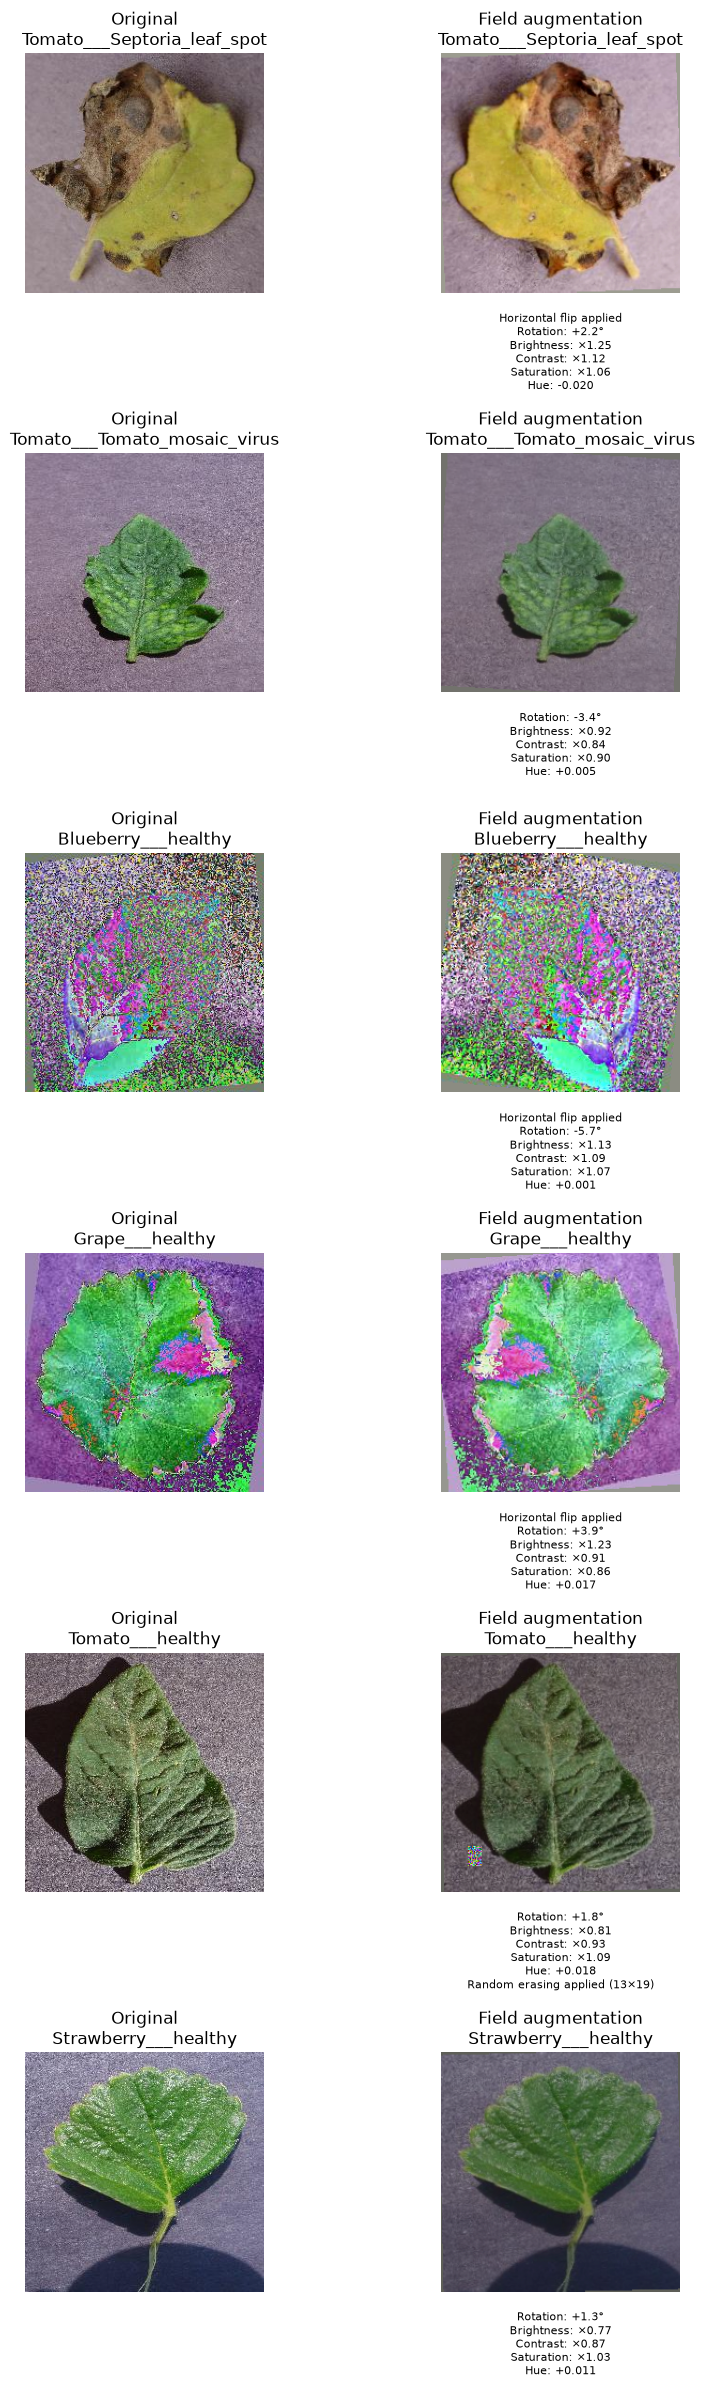

In [37]:
# Select six different classes.
selected_classes = (train_df["class_name"].drop_duplicates().sample(n=min(6, train_df["class_name"].nunique()),random_state=42).tolist())

fig, axes = plt.subplots( nrows=len(selected_classes), ncols=2, figsize=(9, 4 * len(selected_classes)))

# Handle the case where only one class is selected.
if len(selected_classes) == 1:
    axes = [axes]

for row_index, class_name in enumerate(selected_classes):
    # Select one image from the current class.
    class_sample = train_df[train_df["class_name"] == class_name].sample(n=1,random_state=42).iloc[0]
    image_path = class_sample["filepath"]
    with Image.open(image_path) as image:
        original = image.convert("RGB")

    # Create one field-oriented augmented version.
    #augmented_tensor = field_train_transform(original)
    augmented_tensor,labels = labelled_field_augmentation(original)
    augmented = tensor_to_display_image(augmented_tensor)

    # Original image.
    axes[row_index][0].imshow(original)
    axes[row_index][0].set_title(f"Original\n{class_name}")
    axes[row_index][0].axis("off")

    # Augmented image.
    axes[row_index][1].imshow(augmented)
    axes[row_index][1].set_title(f"Field augmentation\n{class_name}")
    axes[row_index][1].axis("off")
    axes[row_index][1].text(0.5, -0.08,"\n".join(labels), transform=axes[row_index][1].transAxes, ha="center", va="top", fontsize=8)


# convert this to landscape orientation for better viewing
plt.tight_layout()
plt.show()

In [38]:
from torchvision.transforms.functional import to_pil_image
from pathlib import Path

output_folder = PROJECT_ROOT / "field_images_augmented"
output_folder.mkdir(parents=True, exist_ok=True)

for index, image_path in enumerate(df["filepath"]):
    image = Image.open(image_path).convert("RGB")
    augmented_tensor = field_train_transform(image)

    # Undo normalization before saving
    mean_tensor = torch.tensor(train_mean, dtype=augmented_tensor.dtype).view(3, 1, 1)
    std_tensor = torch.tensor(train_std, dtype=augmented_tensor.dtype).view(3, 1, 1)
    save_tensor = (augmented_tensor * std_tensor + mean_tensor).clamp(0, 1)

    augmented_image = to_pil_image(save_tensor)

    src = Path(image_path)
    save_path = output_folder / f"{src.stem}_aug{index + 1}.jpg"
    augmented_image.save(save_path)

print(f"Saved augmented images to: {output_folder.resolve()}")

Saved augmented images to: C:\Users\KBE\Desktop\plant-disease-project\field_images_augmented


In [39]:
#count of images in output folder
augmented_image_count = len(list(output_folder.glob("*.jpg")))
print(f"Total augmented images saved: {augmented_image_count}")

Total augmented images saved: 228554


Number of classes : 38
Majority class    : Orange___Haunglongbing_(Citrus_greening)
Accuracy          : 0.190
Macro-F1          : 0.008


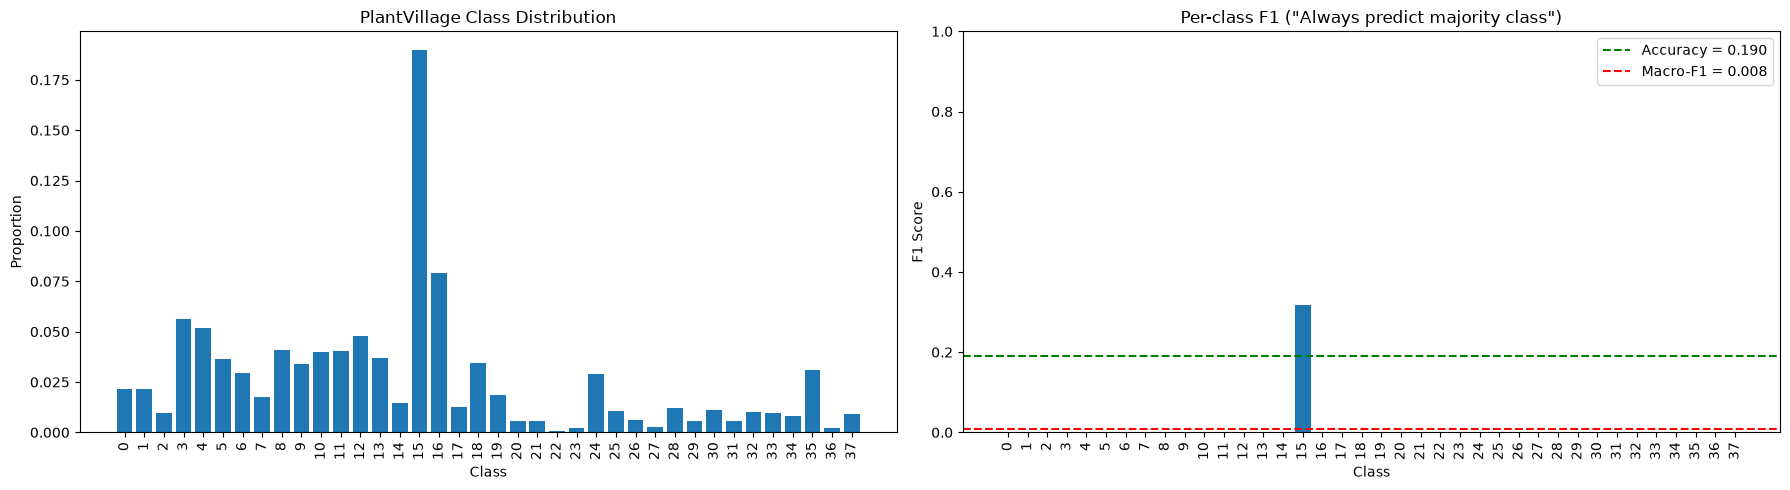

In [40]:
# 6 · Class imbalance & why macro-F1 is used

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Encode class names as integers
encoder = LabelEncoder()
y_true = encoder.fit_transform(df["class_name"])

# Number of classes
num_classes = len(encoder.classes_)

# Majority class
majority_class = np.bincount(y_true).argmax()

# Lazy classifier: predicts only the majority class
y_pred_lazy = np.full_like(y_true, majority_class)

# Metrics
accuracy = accuracy_score(y_true, y_pred_lazy)

macro_f1 = f1_score(
    y_true,
    y_pred_lazy,
    average="macro",
    zero_division=0
)

per_class_f1 = f1_score(
    y_true,
    y_pred_lazy,
    labels=range(num_classes),
    average=None,
    zero_division=0
)

# Actual class distribution
class_counts = df["class_name"].value_counts().sort_index()
class_distribution = class_counts / class_counts.sum()

print(f"Number of classes : {num_classes}")
print(f"Majority class    : {encoder.classes_[majority_class]}")
print(f"Accuracy          : {accuracy:.3f}")
print(f"Macro-F1          : {macro_f1:.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Class distribution
axes[0].bar(range(num_classes), class_distribution)
axes[0].set_title("PlantVillage Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Proportion")
axes[0].set_xticks(range(num_classes))
axes[0].tick_params(axis="x", rotation=90)

# Per-class F1
axes[1].bar(range(num_classes), per_class_f1)

axes[1].axhline(
    accuracy,
    linestyle="--",
    color="green",
    label=f"Accuracy = {accuracy:.3f}"
)

axes[1].axhline(
    macro_f1,
    linestyle="--",
    color="red",
    label=f"Macro-F1 = {macro_f1:.3f}"
)

axes[1].set_title('Per-class F1 ("Always predict majority class")')
axes[1].set_xlabel("Class")
axes[1].set_ylabel("F1 Score")
axes[1].set_xticks(range(num_classes))
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()